Here we will learn diff types of workflows:

    1. Sequential 
    2. Parallel
    3. Conditional
    4. Iterative
    
We will learn each one of them via non-LLM example as well as LLM example.

## Loading API Key

In [11]:
from dotenv import load_dotenv
load_dotenv()

True

## Sequential Workflow
### Non-LLM Example
Here we will see below a BMI calculation workflow.

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
# define state
class BMIState(TypedDict): 
  weight_kg: float
  height_m: float
  bmi: float

In [5]:
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight/(height**2)
  state['bmi'] = round(bmi, 2)
  return state

- This `calculate_bmi` functions's input and output both are state objects.
- When it's taking `BMIState` as input, it's getting all variables in BMIState according to if something will be optional or with predefined value list or any other specification but this can be done.
- Schema enforcing can be done via pydantic. TypedDict only hints during development about input variable (TODO: Read if pydantic be used instead of TypedDict).

**Steps of defining Graph**:
- For defining `graph`, `StateGraph` class should be initiated with `BMIState` as input.
- Then add `nodes`. Here nodes indicate `functionality`.
- Then define `edges`, edges define `direction of execution of functionality (nodes)`.
- `START` and `END` are predefined nodes which indicate `start and end nodes`.
- Next compile the graph (TODO: explain this step)

In [6]:
# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

# compile the graph
workflow= graph.compile()

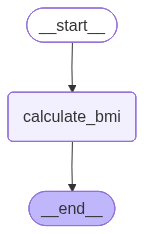

In [7]:
# visualize the graph before executing
workflow

In [8]:
# execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


- This is a basic example to understand how to make graph in LangGraph. 
- Next we will see above workflow with another variable `category` in `BMIState`. 

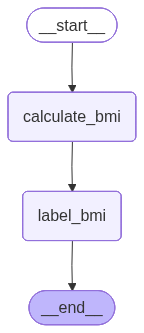

In [9]:
# added new variable `category`
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float
  category: str

# same function as earlier
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight/(height**2)
  state['bmi'] = round(bmi, 2)
  return state

# new function to get category according to bmi
def label_bmi(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi<18.5:
    state['category'] = "Underweight"
  elif 18.5<bmi<25:
    state['category'] = "Normal"
  elif 25<bmi<30:
    state['category'] = "Overweight"
  else:
    state['category'] = 'Obese'
  return state



# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()
workflow

In [10]:
# execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


- Will see example of LLM one next. 
- We will see proper complex graphs later.

### LLM Example

In [12]:
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re


# define prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

# define LLM
model = ChatOpenAI()

In [13]:
class LLMState(TypedDict):
  question: str
  answer: str

In [14]:
def llm_qa(state: LLMState) -> LLMState:

  # extract the question from state
  question = state['question']

  # form a prompt
  prompt = f"Answer the following question: {question}"

  # ask that question to the LLM
  answer = model.invoke(prompt).content

  # update the answer in the state
  state['answer'] = answer

  return state

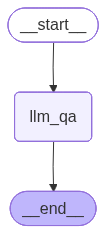

In [15]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()
workflow

In [16]:
initial_state = {'question': 'How far is moon from Earth?'}
final_state = workflow.invoke(initial_state)
final_state

{'question': 'How far is moon from Earth?',
 'answer': 'The average distance between the Earth and the Moon is approximately 238,855 miles (384,400 kilometers).'}

In [17]:
final_state['answer']

'The average distance between the Earth and the Moon is approximately 238,855 miles (384,400 kilometers).'

### Prompt Chaining
- We will see example of blog generation workflow.
- Here directly topic will not be generated, first outline will be generated, then based on topic+outline blog will be generated.
- LLM will interacted two times once via outline and next via blog.

In [18]:
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

model = ChatOpenAI()

In [19]:
class BlogState(TypedDict):
  title: str
  outline: str
  content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:

  # fetch title
  title = state['title']

  # create prompt
  prompt = f"Generate a detailed outline for a blog on the topic - {title}" 

  # call llm to generate outline
  outline = model.invoke(prompt).content

  # update state
  state['outline'] = outline

  # return state
  return state

In [21]:
def create_blog(state: BlogState) -> BlogState:

  # fetch title and outline
  title = state['title']
  outline = state['outline']

  # create prompt
  prompt = f"Generate a detailed blog on the title - {title} using the following \n {outline}"

  # call llm generate blog
  content = model.invoke(prompt).content

  # update state
  state['content'] = content

  # return state
  return state

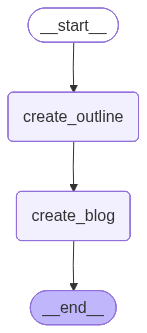

In [22]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()
workflow

In [23]:
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': "I. Introduction\n   A. Explanation of AI\n   B. Importance of AI in today's world\n   C. Overview of AI in India\n\nII. Historical background of AI in India\n   A. Early developments in AI in India\n   B. Key players and institutions in AI research in India\n   C. Challenges faced in the adoption of AI in India\n\nIII. Current state of AI in India\n   A. Growth of AI startups in India\n   B. Adoption of AI in various industries in India\n   C. Government initiatives to promote AI in India\n\nIV. Impact of AI on the Indian economy\n   A. Job displacement and creation due to AI\n   B. Potential growth opportunities for businesses in India\n   C. Challenges for low skilled workers in the age of AI\n\nV. Future prospects of AI in India\n   A. Potential for AI to transform key industries in India\n   B. Opportunities for further research and development in AI\n   C. Challenges and potential roadblocks for the growth of AI in India\n\nVI. Case stu

In [24]:
print(final_state.keys())

dict_keys(['title', 'outline', 'content'])


In [25]:
print(final_state['title'])

Rise of AI in India


In [26]:
print(final_state['outline'])

I. Introduction
   A. Explanation of AI
   B. Importance of AI in today's world
   C. Overview of AI in India

II. Historical background of AI in India
   A. Early developments in AI in India
   B. Key players and institutions in AI research in India
   C. Challenges faced in the adoption of AI in India

III. Current state of AI in India
   A. Growth of AI startups in India
   B. Adoption of AI in various industries in India
   C. Government initiatives to promote AI in India

IV. Impact of AI on the Indian economy
   A. Job displacement and creation due to AI
   B. Potential growth opportunities for businesses in India
   C. Challenges for low skilled workers in the age of AI

V. Future prospects of AI in India
   A. Potential for AI to transform key industries in India
   B. Opportunities for further research and development in AI
   C. Challenges and potential roadblocks for the growth of AI in India

VI. Case studies of successful AI implementation in India
   A. Healthcare sector


In [27]:
print(final_state['content'])



I. Introduction

A. Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes include learning, reasoning, problem-solving, perception, and even language understanding. AI has become increasingly important in today's world as technology continues to advance at a rapid pace.

B. AI has the potential to revolutionize industries, improve efficiency and productivity, and enhance customer experiences. From chatbots and virtual assistants to self-driving cars and recommendation systems, AI has already permeated various aspects of our daily lives.

C. In India, the adoption of AI is steadily increasing as businesses and organizations recognize the benefits it can bring. With a growing tech-savvy population and a strong focus on innovation and entrepreneurship, India is poised to capitalize on the rise of AI.

II. Historical background of AI in India

A. India has a long history of contributions to the fi

- If we make this workflow in `LangChain`, then we will get only content at end, not title as we are getting in `LangGraph`, because in `LangChain` only end result is availble, but in `LangGraph` state is keeping track of all variables at every stage.
- TODO: 
    - Add node to evaluate: node `evaluate_blog`.
    - Prompt should be: `Based on {outline} read my blog, generate an internal score.`

## Parallel Workflow
### Non-LLM Example
- Here we will see an example where three functionalities will be placed.
- To calculate strike rate (SR), balls per boundary (BPB) and boundary percentage from number of fours and sixes in a cricket match.
- These three metrics can be calculated parallely, they are only dependent on number of fours and sixes not on one other.

In [29]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [28]:
class BatsmanState(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  sr: float 
  bpb: float 
  boundary_percent: float
  summary: str

In [31]:
def calculate_sr(state: BatsmanState):
  sr = (state['runs']/state['balls'])*100
  return {'sr': sr}

def calculate_bpb(state: BatsmanState):
  bpb = state['balls']/(state['fours']+state['sixes'])
  return {'bpb': bpb}

def calculate_boundary_percent(state: BatsmanState):
  boundary_percent = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
  return {'boundary_percent': boundary_percent}

def summary(state: BatsmanState):
  summary = f"""
  Strike Rate - {state['sr']} \n
  Balls per boundary - {state['bpb']} \n
  Boundary percent - {state['boundary_percent']} 
  """
  return {'summary': summary}

```python
def calculate_sr(state: BatsmanState):
  sr = (state['runs']/state['balls'])*100
  state['sr'] = sr
  return state

def calculate_bpb(state: BatsmanState):
  bpb = state['balls']/(state['fours']+state['sixes'])
  state['bpb'] = bpb
  return state

def calculate_boundary_percent(state: BatsmanState):
  boundary_percent = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
  state['boundary_percent'] = boundary_percent
  return state

def summary(state: BatsmanState):
  summary = f"""
  Strike Rate - {state['sr']} \n
  Balls per boundary - {state['bpb']} \n
  Boundary percent - {state['boundary_percent']} 
  """
  state['summary'] = summary
  return state
```

- As we saw in sequential workflow, for this case ideally code should be like this i.e. in each function storing corresponsing variable and returning entire `state`.
- But here nodes (methods) are retuning only variable corresponding to that method. 

**Reason:**
- In parallel workflow all these nodes will be running parallelly. Now if each node will return the entire `state`, LangGraph will think all variables are changed from all nodes.
- So there will conflict happen as any node will change only its corresponding variable, while keeping others as it is. This error is called invalid calculation error. Here in the output from all nodes at same time differet state variable (sr, bpb etc) will have different values. 
- To avoid this issue, we return only one variable which is calculated by that node instead of entire `state as shown in the cell. 
- This happens only in parallel workflow, not in seqential (if in iterative or conditional workflow any parralel workfloe will be there, it will face same if we will return entire `state` as shown above). 
- This way of returning that particular variable in dictionary format (as shown in python cell above) is called - `partial update`. 
- This works in sequentual and paralel both workflows. So as recommendation we can always work on this only.

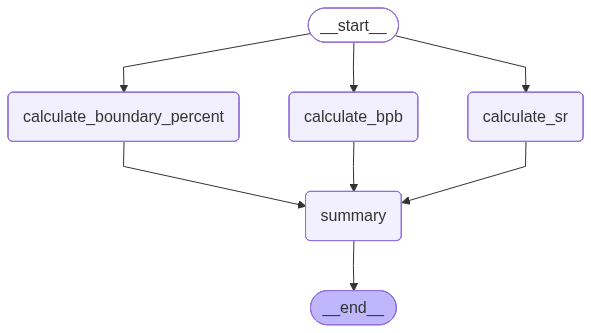

In [32]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
workflow

In [33]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n  Strike Rate - 200.0 \n\n  Balls per boundary - 5.0 \n\n  Boundary percent - 48.0 \n  '}

### LLM Example
- Here we will see workflow on UPSC essay evaluation - (see video for story).
- Three things to implement here (this is not a veru trivial workflow):
    - Parallel workflow
    - Structured Output
    - Reducers 
- Here we will keep three evaluators.
- **Why reducer is needed?**
    - We will get here scores from three evaluators, and we have to list out them to get final feedback. In reducers by default it's `replacement` option, but we want to keep scores from all three evaluators. So we have to use reducer `add` not the default one.
    - In case of `replace` reducer, score of one ealuator will be replaced by score of another evaluator.

- We have to choose that LLM, which supports structured oouput e.g. HuggingFace don't support structured output.

In [34]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

model = ChatOpenAI(model = 'gpt-4o-mini')

- To make sure output will be text output as well as score, we'll use structured output as below.

In [36]:
class EvaluationSchema(BaseModel):
  feedback: str = Field(description='Detailed feedback for the essay')
  score: int = Field(description = 'score out of 10', ge=0, le=10)

- We have to create this structured model to get output in mentioned format of `EvaluationSchema`.

In [37]:
structured_model = model.with_structured_output(EvaluationSchema)

In [40]:
essay = """India is rapidly emerging as a significant player in the field of Artificial Intelligence (AI), shaping both its domestic growth and its global influence. With a large pool of skilled professionals, a strong IT industry, and increasing government support, India is positioning itself as a hub for AI innovation and development.

One of the key strengths of India in AI lies in its vast talent base. Every year, thousands of engineers and data scientists graduate from Indian institutions, contributing to the growing workforce in AI and related technologies. Indian professionals are actively involved in developing AI solutions across industries such as healthcare, agriculture, finance, and education.

The government of India has also taken several initiatives to promote AI. Programs like the National Strategy for Artificial Intelligence focus on using AI for social good. The aim is to improve areas such as healthcare services, smart cities, agriculture productivity, and education systems. By encouraging research, funding startups, and building digital infrastructure, the government is helping create a supportive ecosystem for AI growth.

India’s IT companies play a major role in advancing AI technologies. Many Indian firms are investing in AI research and integrating it into their services. Additionally, global tech companies have established research centers in India, further boosting innovation and collaboration.

AI is also helping solve real-world problems in India. For example, AI-powered tools are being used in agriculture to predict crop yields and detect diseases. In healthcare, AI helps in early diagnosis and improving patient care. In education, it supports personalized learning experiences for students.

However, India also faces challenges in AI development. Issues such as data privacy, lack of advanced infrastructure in rural areas, and the need for better AI education and training must be addressed. Ensuring ethical use of AI and preventing job displacement are also important concerns.

In conclusion, India plays an important and growing role in the field of Artificial Intelligence. With its strong talent pool, supportive policies, and increasing adoption across sectors, India has the potential to become a global leader in AI while also using technology to improve the lives of its people.
"""

In [41]:
prompt = f"Evaluate the language of the following essay and provide a feedback and assign a score out of 10 \n {essay}"

- Here we are checking how normal `model` is giving output, to see if explicitly schena is not defined, how outputs are coming.
- It may or may not generate `feedback` and `score` seperately as required for our usecase.

In [47]:
model.invoke(prompt)

AIMessage(content="**Feedback on the Essay:**\n\n1. **Clarity and Coherence**: The essay presents a clear and coherent argument about India's growing role in the field of Artificial Intelligence. Each paragraph logically flows to the next, with a well-defined structure that covers India's strengths, government initiatives, contributions from the IT sector, practical applications, and challenges.\n\n2. **Content and Depth**: The essay effectively highlights several key aspects of AI development in India, such as the talent pool, government support, and real-world applications. The examples provided (agriculture, healthcare, and education) are relevant and help illustrate the impact of AI. However, it could have included deeper insights into the specific challenges faced, or provided more examples of successful AI implementations to add depth.\n\n3. **Language and Style**: The language is mostly formal and appropriate for an academic or professional audience. There is a good use of termi

- In current `model` output no score is generated. It may happen in some invoke, it will benerate `score` as well.
- This is the reason we are using `structured_model`.

- Below `structured_model` witll generate output according to schema shared above.
- Normal model will not be able to generate in same way. So we used `structured_model`.

In [48]:
result = structured_model.invoke(prompt) 
result

EvaluationSchema(feedback="The essay presents a well-structured analysis of India's position in the field of Artificial Intelligence, highlighting its strengths, initiatives, and challenges. The language used is clear and concise, making it easy for the reader to understand the main points. However, there could be more depth in discussing the ethical concerns associated with AI and potential solutions to the challenges mentioned. Additionally, incorporating specific examples or statistics could strengthen the arguments made. Overall, the essay is informative and well-written, but could benefit from further elaboration on certain points.", score=8)

- `structured_model` can generate different feedback and different scores in each invokation.

In [49]:
result.feedback

"The essay presents a well-structured analysis of India's position in the field of Artificial Intelligence, highlighting its strengths, initiatives, and challenges. The language used is clear and concise, making it easy for the reader to understand the main points. However, there could be more depth in discussing the ethical concerns associated with AI and potential solutions to the challenges mentioned. Additionally, incorporating specific examples or statistics could strengthen the arguments made. Overall, the essay is informative and well-written, but could benefit from further elaboration on certain points."

In [50]:
result.score

8

- `reducer` is `operator.add` to list up all scores from three evaluators.
- General working of `operator.add` reducer:
     ```python 
     [0]+[5] -> [0, 5]
     ``` 
- Added reducer in `individual_scores` variable.

In [ ]:
class UPSCState(TypedDict):
  essay: str
  language_feedback: str
  analysis_feedback: str
  clarity_feedback: str
  overall_feedback: str
  individual_scores: Annotated[list[int], operator.add] 
  avg_score: float

In [57]:
def evaluate_language(state: UPSCState):
  prompt = f"Evaluate the language of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
  prompt = f"Evaluate the depth of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
  prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
  # summary feedback
  prompt = f"Based on the following feedbacks create a summarized feedback\n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']},\n clarity of thought feedback - {state['clarity_feedback']}"
  overall_feedback = model.invoke(prompt).content
  # avg calculate
  avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
  return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

- For node `final_evaluation` we will not use `structured_model` because it can generate another score, which is not required here. 
- So used `model.invoke(prompt).content` instead of `structured_model.invoke(prompt)` of rest three evaluators.
- Also note, `individual_scores` is list for all three, which will be appended via `operator.add` reducer later.

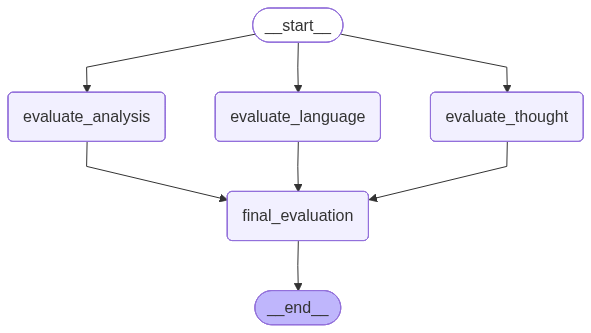

In [58]:
graph = StateGraph(UPSCState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)


# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()
workflow


In [59]:
initial_state = {
    'essay': essay
}

In [60]:
workflow.invoke(initial_state)

{'essay': 'India is rapidly emerging as a significant player in the field of Artificial Intelligence (AI), shaping both its domestic growth and its global influence. With a large pool of skilled professionals, a strong IT industry, and increasing government support, India is positioning itself as a hub for AI innovation and development.\n\nOne of the key strengths of India in AI lies in its vast talent base. Every year, thousands of engineers and data scientists graduate from Indian institutions, contributing to the growing workforce in AI and related technologies. Indian professionals are actively involved in developing AI solutions across industries such as healthcare, agriculture, finance, and education.\n\nThe government of India has also taken several initiatives to promote AI. Programs like the National Strategy for Artificial Intelligence focus on using AI for social good. The aim is to improve areas such as healthcare services, smart cities, agriculture productivity, and educat

- TODO: 
    - Generate another essay with intential bad english and spelling mistakes.
    - Test with above code, then evaluators will give bad scores - see how it works.
    - Read about `reducer` concept, it was in `LangChain` playlist. `operator` in python's base module. It's function format of normal mathematical operations. Read about it from `python` playlist.

## Conditional Workflow
- Here any one branch will work based on condition, never two branches will be executed together.
### Non-LLM Example
- We'll see quadratic equation solve example.

In [61]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [62]:
class QuadState(TypedDict):
  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [63]:
def show_equation(state: QuadState):
  equation = f"{state['a']}X2+{state['b']}x+{state['c']}"
  return {'equation': equation}

def calculate_discriminant(state: QuadState):
  discriminant = state['b']**2 - (4*state['a']*state['c'])
  return {'discriminant': discriminant}

def real_roots(state: QuadState):
  root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
  root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
  result = f'The roots are {root1} and {root2}'
  return {'result': result}

def repeated_roots(state: QuadState):
  root = (-state['b'])/(2*state['a'])
  result = f'Only repeating root is {root}'
  return {'result': result}

def no_real_roots(state: QuadState):
  result = f'No real root'
  return {'result': result}

# routing function
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
  if state['discriminant']>0:
    return "real_roots"
  elif state['discriminant']==0:
    return "repeated_roots"
  else:
    return "no_real_roots"

- First here is equation showing and calculating discriminant.
- Till here no conditional branching.
- Based on the `discriminant`, condtions will work.

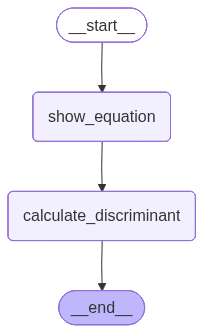

In [64]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', END)

workflow= graph.compile()
workflow

In [65]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
    }

workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4X2+-5x+-4', 'discriminant': 89}

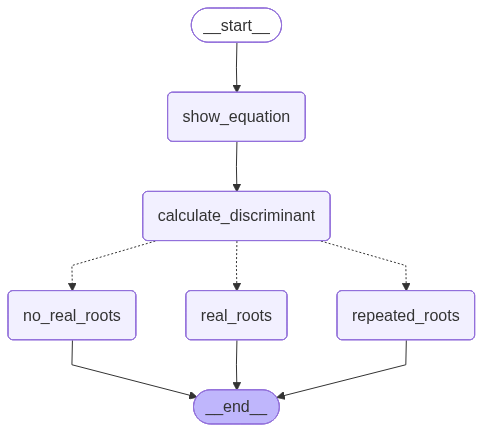

In [67]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()
workflow

- Here we'll see three conditional branches: `no_real_roots`, `real_roots`, `repeated_roots`.
- See execution of workflow with different examples. 

In [68]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
    }

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4X2+-5x+-4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}

In [69]:
initial_state = {
    'a': 4,
    'b': 2,
    'c': 4
    }

workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4X2+2x+4',
 'discriminant': -60,
 'result': 'No real root'}

In [70]:
initial_state = {
    'a': 2,
    'b': 4,
    'c': 2
    }

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2X2+4x+2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}

- TODO: To make equation printing in proper format.

### LLM Example
- Here we'll see `Review Handling` workflow.

In [71]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import operator
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

model = ChatOpenAI(model = 'gpt-4o-mini')

In [ ]:
# output schema
class SentimentSchema(BaseModel):
  sentiment: Literal["positive", "negative"] = Field(description= 'Sentiment of the review')

In [73]:
structured_model = model.with_structured_output(SentimentSchema)

In [74]:
# output schema
class DiagnosisSchema(BaseModel):
  issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
  tone: Literal["angry", "frustrated", "disappoined", "calm"] = Field(description='The emotional tone expressed by the user')
  urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [75]:
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [76]:
prompt = "What is the sentiment of the following review - the software too good"
structured_model.invoke(prompt).sentiment

'positive'

In [77]:
prompt = "What is the sentiment of the following review - the software too bad"
structured_model.invoke(prompt).sentiment

'negative'

- Defining `TypedDict` class below, i.e. int, float these are also classes defined in python, so here we are defining our required datatype for later functions.

In [78]:
class ReviewState(TypedDict):
  review: str
  sentiment: Literal["positive", "negative"]
  diagnosis: dict
  response: str

In [ ]:
def find_sentiment(state: ReviewState):
  prompt = f"For the following review find out the sentiment \n {state['review']}"
  sentiment = structured_model.invoke(prompt).sentiment
  return {'sentiment': sentiment}

In [80]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
  if state['sentiment'] == 'positive':
    return "positive_response"
  else:
    return "run_diagnosis"

In [97]:
def positive_response(state: ReviewState):
  prompt = f"""Write a warm thank you message in response to this review: \n\n\"{state['review']}\"\n Also, kindly ask the user to leave feedback on our website."""
  response = model.invoke(prompt).content
  return {'response': response}

In [98]:
def run_diagnosis(state: ReviewState):
  prompt = f"""Diagnose this negative review:\n\n{state['review']}\n. return issue_type, tone, and urgency"""
  response = structured_model2.invoke(prompt)
  return {'diagnosis': response.model_dump()}

In [99]:
def negative_response(state: ReviewState):
  diagnosis = state['diagnosis']
  prompt = f"""You are a support assistant. The user had a "{diagnosis['issue_type']}" issue, sounded "{diagnosis['tone']}", and marked urgency as "{diagnosis['urgency']}". Write an empathetic, helpful resolution message."""
  response = model.invoke(prompt).content
  return {'response': response}

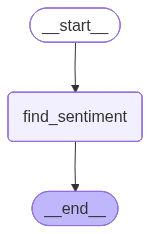

In [100]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)

graph.add_edge(START, 'find_sentiment')
graph.add_edge('find_sentiment', END)

workflow= graph.compile()
workflow

- Here we just implemented finding sentiment, not later steps.
- See few examples.

In [101]:
initial_state = {
    'review': 'The product is really good'
}
workflow.invoke(initial_state)

{'review': 'The product is really good', 'sentiment': 'positive'}

In [102]:
initial_state = {
    'review': 'The product is really bad'
}
workflow.invoke(initial_state)

{'review': 'The product is really bad', 'sentiment': 'negative'}

- Let's define the full workflow. 

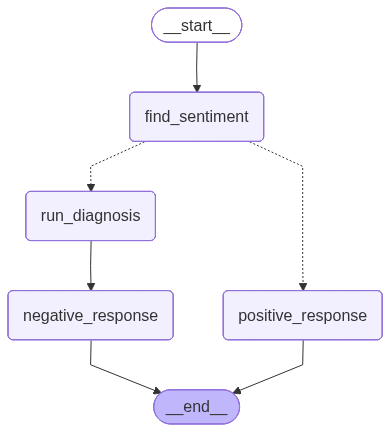

In [103]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow= graph.compile()
workflow

In [104]:
initial_state = {
    'review': 'This product delivers excellent quality and performance, making it a reliable and satisfying choice for everyday use.'
}
workflow.invoke(initial_state)

{'review': 'This product delivers excellent quality and performance, making it a reliable and satisfying choice for everyday use.',
 'sentiment': 'positive',
 'response': "Dear [Customer's Name],\n\nThank you so much for your wonderful review! We’re thrilled to hear that you find our product to be of excellent quality and performance. It's always our goal to provide reliable solutions for our customers, and your feedback truly brightens our day. \n\nIf you have a moment, we’d greatly appreciate it if you could share your thoughts on our website as well. Your insights help us continue to improve and assist other customers in making informed choices.\n\nThank you once again for your support!\n\nWarm regards,  \n[Your Name/Your Company Name]"}

In [105]:
initial_state = {
    'review': 'This product falls short in quality and performance, making it a disappointing choice for everyday use.'
}
workflow.invoke(initial_state)


{'review': 'This product falls short in quality and performance, making it a disappointing choice for everyday use.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'disappoined',
  'urgency': 'medium'},
 'response': "Subject: We're Here to Help You with Your Performance Issue\n\nHi [User’s Name],\n\nI hope this message finds you well. I understand that you've been experiencing performance issues, and I want you to know that I'm here to help you resolve this as quickly as possible. I can imagine how frustrating it must be for you, especially when you're trying to get things done.\n\nTo better assist you, could you please provide me with a few details? Specifically, it would be helpful to know:\n\n1. What specific performance issues you are encountering (e.g., slow loading times, application crashes, etc.).\n2. The device and software version you are using.\n3. Any steps you’ve already tried to resolve the issue.\n\nWith this information, I’ll be better 

## Iterative Workflow
- Here we'll learn workflow which will run in a loop.
### Non-LLM Example

In [108]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator

- Here in real life implementation we should evaluate which model is good for different mentioned works, but as this is dummy project, we are using same small size model at all three places.

In [107]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [109]:
class TweetEvaluation(BaseModel):
  evaluation: Literal['approved', 'needs_improvement'] = Field(..., description='Final evaluation result.')
  feedback: str = Field(..., description='Constructive feeedback for the tweet.')


- Output from evaluator LLM will be generated in given format in `TweetEvaluation` schema.

In [110]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation) 

In [119]:
# defining state object for tweet
class TweetState(TypedDict):
  topic: str
  tweet: str
  evaluation: Literal['approved', 'needs_improvement']
  feedback: str
  iteration: int
  max_iteration: int 

  tweet_history: Annotated[list[str], operator.add]
  feedback_history: Annotated[list[str], operator.add]

- Here if there is strict evaluation criteria then workflow can go to infinite loop i.e. it will keep regenerating and reevaluating till it's getting positive feedbnack from evaluators.
- So we are keeping a varaible `max_iteration` to break this infinite loop.
- Wherever we are working with `loop` or `retries`, we should keep this `max_iteration` limit.

In [120]:
def generate_tweet(state: TweetState):

  # prompt
  messages = [
      SystemMessage(content='You are a funny and clever Twitter/X influencer.'),
      HumanMessage(content = f"""
      Write a short, original and hilarious tweet on the topic: '{state['topic']}',
      Rules:
      - Do NOT use question-answer format.
      - Max 200 characters.
      - Use observational humor, irony, sarcasm or cultural references.
      - Use simple, day to day english.
      - This is version {state['iteration']+1}""")
  ]

  # send to generator llm
  response = generator_llm.invoke(messages).content

  # return response
  return {'tweet': response, 'tweet_history': [response]}

In [121]:
def evaluate_tweet(state: TweetState):

  # prompt
  messages = [
      SystemMessage(content='You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality and tweet format.'),
      HumanMessage(
      content = f"""
      Evaluate the following tweet:

      Tweet: "{state['tweet']}"

      Use the criteria below to evaluate the tweet:

      1. Originality - Is this fresh, or have you seen it hundred times before?
      2. Humor - Did it genuinely make you smile, laugh or chuckle?
      3. Punchiness - Is it short, sharp and scroll-stopping?
      4. Virality Potential - Would people retweet or share it?
      5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 200 characters)?

      Auto-reject if:
      - It's written in question-answer format (e.g. 'Why did .....' or 'What happens when .....')
      - It exceeds 200 characters.
      - It reads like traditional setup-punchline joke.
      - Don't end with generic, throwaway or deflating lines that weaken the humor (e.g. 'Masterpieces of the auntie-uncle universe' or vague summaries)

      ### Respond ONLY in structured format:
      - Evaluation: 'approved' or 'needs_improvement'
      - Feedback: One paragraph explaining the strength and weaknesses
      """
      )
  ]

  response = structured_evaluator_llm.invoke(messages)
  return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [122]:
def optimize_tweet(state: TweetState):
  messages = [
      SystemMessage(content='You punch up tweets for virality and humor based on given feedback.'),
      HumanMessage(content = f"""
      Improve the tweet based on this feedback:
      "{state['feedback']}"

      Topic: "{state['topic']}"
      Original Tweet:
      {state['tweet']}

      Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
      """)
  ]

  response = optimizer_llm.invoke(messages).content
  iteration = state['iteration'] + 1
  return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [123]:
# decision making function
def route_evaluation(state: TweetState):
  if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
    return 'approved'
  else:
    return 'needs_improvement'

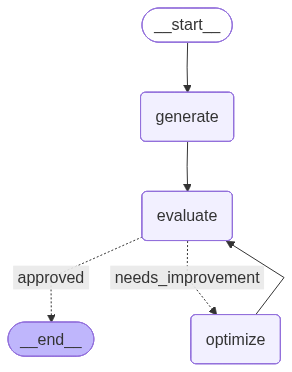

In [124]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)


graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow

In [125]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iteration": 5
}

result = workflow.invoke(initial_state)
result

{'topic': 'Indian Railways',
 'tweet': 'Indian Railways: where you can travel across the country while simultaneously getting a free sauna, spa, and survival training in the art of finding a seat. #TrainLife 🚂💦✨',
 'evaluation': 'approved',
 'feedback': 'This tweet successfully combines humor with originality, portraying a relatable experience of Indian Railways in a humorous light. The metaphor of a free sauna and survival training cleverly encapsulates the realities of train travel in India, making it fresh and engaging. Its punchiness is evident, managing to convey a full scenario within a concise format. The potential for virality is high, as it appeals to a broad audience familiar with train travel. Overall, it meets the criteria effectively and showcases a well-formed structure.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Indian Railways: where you can travel across the country while simultaneously getting a free sauna, spa, and survival training in the art of fin

In [ ]:
for tweet in result['tweet_history']:
  print(tweet)

Indian Railways: where you can travel across the country while simultaneously getting a free sauna, spa, and survival training in the art of finding a seat. #TrainLife 🚂💦✨


- Let's write some gibberish tweet to see iterations.

In [129]:
initial_state = {
    "topic": "Write a Q&A joke in 500 words first, then optimize",
    "iteration": 1,
    "max_iteration": 5
}

result = workflow.invoke(initial_state)
result

{'topic': 'Write a Q&A joke in 500 words first, then optimize',
 'tweet': 'Writing a Q&A joke in 500 words? That’s like trying to bake a cake with just flour—no one’s laughing and everyone’s looking for the exit! 🍰😂 Remember: a sprinkle of brevity goes a long way! #ComedyCooking #BakingFails',
 'evaluation': 'needs_improvement',
 'feedback': "The tweet attempts to blend humor and a cooking metaphor, but it falls flat in originality, as the cake metaphor has been done repeatedly. The humor is weak and may only elicit a mild chuckle rather than a genuine laugh. It's also a bit lengthy for a tweet, and while it has a playful premise, it lacks the punchiness needed to make it truly scroll-stopping. Moreover, the concluding line feels like a generic tip rather than a strong finish, which weakens the overall impact.",
 'iteration': 5,
 'max_iteration': 5,
 'tweet_history': ['Writing a Q&A joke in 500 words is like baking a cake with one ingredient—you\'re just going to end up with a mess! "O

In [130]:
for tweet in result['tweet_history']:
  print(tweet)

Writing a Q&A joke in 500 words is like baking a cake with one ingredient—you're just going to end up with a mess! "Optimized" means I’ve added sprinkles, right? 🍰✨
Writing a Q&A joke in 500 words is like trying to bake a cake with one ingredient: it’s a recipe for disaster! 😅 And just because I added sprinkles doesn’t mean it magically tastes better. 🍰✨ Let’s face it, at this point, we’re just serving up confusion!
Writing a Q&A joke in 500 words? That’s like trying to bake a cake with just flour—confusing and a recipe for disaster! 🍰 Just tossing on sprinkles won’t save it. At this rate, we're not serving laughs; we're dishing out disaster! 😂✨ #ComedyCooking
Writing a Q&A joke in 500 words is like trying to bake a cake with only flour—just a weird mix of confusion! 🍰 Spoiler: No amount of sprinkles can rescue that disaster. We're not serving laughs; we're just baking bloopers! 😂✨ #ComedyCooking
Writing a Q&A joke in 500 words? That’s like trying to bake a cake with just flour—no one’